# Detección de Intrusiones en Redes IoT mediante Machine Learning
## Análisis Completo sobre CICIoT2023

---

**Universidad del Valle de Guatemala**  
**Curso:** Security Data Science — Semestre I, 2026  
**Autores:** Sebastian Huertas · Sofía Velásquez

---

### Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| **1. Dataset** | Construcción, descarga y consolidación del dataset CICIoT2023 |
| **2. EDA** | Análisis exploratorio: distribución de clases, outliers, correlaciones |
| **3. Preprocesamiento** | Limpieza, escalado RobustScaler, balanceo de clases, train/test split |
| **4. Selección de Features (RF)** | Random Forest preliminar + feature importance con corte en 0.001 |

---
# SECCIÓN 1 — Descripción y Construcción del Dataset

## 1.1 Descripción del Dataset CICIoT2023

El **CICIoT2023** (Canadian Institute for Cybersecurity IoT Dataset 2023) fue desarrollado por Neto et al. en la University of New Brunswick. Es uno de los benchmarks más completos y recientes para la evaluación de sistemas de detección de intrusiones en entornos IoT.

### Características principales

- **Topología:** 105 dispositivos IoT heterogéneos en red real
- **Ataques simulados:** 33 tipos distintos (DDoS, DoS, Mirai, Reconocimiento, Spoofing, Web/Malware, Fuerza Bruta)
- **Total de registros:** ~8,450,000 filas
- **Features:** 46 características de tráfico de red + 1 etiqueta
- **Clases:** 34 (33 tipos de ataque + BenignTraffic)
- **Fuente:** [Kaggle - madhavmalhotra/unb-cic-iot-dataset](https://www.kaggle.com/datasets/madhavmalhotra/unb-cic-iot-dataset)

### Categorías de ataque

| Categoría | Descripción | Registros aprox. |
|-----------|-------------|------------------|
| DDoS | Ataques de denegación de servicio distribuido (ICMP, UDP, TCP, SYN, etc.) | 6,155,765 |
| DoS | Denegación de servicio simple (UDP, TCP, SYN, HTTP) | 1,460,921 |
| Mirai | Botnet IoT con variantes de flood | 476,577 |
| Benigno | Tráfico normal legítimo | 197,659 |
| Spoofing | ARP Spoofing, DNS Spoofing | 88,304 |
| Reconocimiento | Host Discovery, OS Scan, Port Scan, Ping Sweep | 57,131 |
| Fuerza Bruta/Scan | Dictionary Brute Force, Vulnerability Scan | 9,176 |
| Web/Malware | XSS, SQL Injection, Command Injection, Backdoor, etc. | 4,467 |

### Desbalance de clases

El dataset presenta un **desbalance severo**: el tráfico benigno representa únicamente el **2.34%** del total, mientras que los ataques constituyen el **97.66%**. Dentro de los ataques, los tipos DDoS dominan ampliamente. Este desbalance es uno de los principales desafíos técnicos del proyecto y fue abordado mediante estrategias de under/oversampling en el preprocesamiento.

## 1.2 Construcción del Dataset

El dataset original en Kaggle está distribuido en **169 archivos CSV** particionados. El proceso de construcción consistió en:

1. Descargar los 169 archivos via la API de Kaggle
2. Leer cada archivo y tomar una muestra de **50,000 filas** por archivo
3. Concatenar todas las muestras en un único DataFrame consolidado
4. Guardar el resultado como `ciciot2023_consolidado.csv` en Google Drive

In [1]:
# Instlar todas las dependencias que creemos necesarias para notebook general.
!pip install kaggle shap imbalanced-learn -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pickle
import warnings
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.utils import resample
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

import shap

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid')

print('Imports completados correctamente.')

Imports completados correctamente.


In [2]:
# Levantar el google drive para acceder a los datos y guardar resultados.
# Pst: Esto lo hicimos porque el dataset es mega jumbo gigante entonces es más fácil trabajar con él desde el drive.
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/'
print(f'Drive montado. Ruta base: {DRIVE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado. Ruta base: /content/drive/MyDrive/


### 1.3 Descarga y Consolidación del Dataset

Las siguientes celdas descargan los datos desde Kaggle y construyen el archivo consolidado.

In [4]:
# En esta celda puede congigurar las credenciales de Kaggle para descargar el dataset directamente desde la plataforma. 
# O también se pueden configurar en VSCode cuando se ejecute el notebook localmente.
"""
import os
import json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_creds = {
    'username': 'TU_USUARIO_KAGGLE',   # <-- Reemplazar
    'key': 'TU_API_KEY_KAGGLE'         # <-- Reemplazar
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Credenciales guardadas correctamente")
"""

'\nimport os\nimport json\n\nos.makedirs("/root/.kaggle", exist_ok=True)\n\nkaggle_creds = {\n    \'username\': \'TU_USUARIO_KAGGLE\',   # <-- Reemplazar\n    \'key\': \'TU_API_KEY_KAGGLE\'         # <-- Reemplazar\n}\n\nwith open("/root/.kaggle/kaggle.json", "w") as f:\n    json.dump(kaggle_creds, f)\n\nos.chmod("/root/.kaggle/kaggle.json", 0o600)\nprint("Credenciales guardadas correctamente")\n'

*Descargar dataset desde KAGGLE*

Tamaño: ~2.77 GB — puede tardar varios minutos

In [5]:
!kaggle datasets download -d madhavmalhotra/unb-cic-iot-dataset -p /content/ciciot2023 --unzip

Dataset URL: https://www.kaggle.com/datasets/madhavmalhotra/unb-cic-iot-dataset
License(s): other
 24% 687M/2.77G [00:27<01:27, 25.9MB/s] 
User cancelled operation


In [ ]:
base_path = "/content/ciciot2023/wataiData/csv/CICIoT2023"
archivos = []

for f in sorted(os.listdir(base_path)):
    if f.endswith(".csv"):
        ruta = os.path.join(base_path, f)
        tam = os.path.getsize(ruta) / (1024 * 1024)
        archivos.append((ruta, round(tam, 2)))
        print(f"{f} — {round(tam, 2)} MB")

print(f"\nTotal de archivos CSV: {len(archivos)}")
print(f"Tamano total: {round(sum(t for _, t in archivos), 2)} MB")


part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 67.08 MB
part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 61.49 MB
part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 77.34 MB
part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 64.9 MB
part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 63.9 MB
part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 67.45 MB
part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 65.66 MB
part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 64.04 MB
part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 69.23 MB
part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 63.95 MB
part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 70.65 MB
part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 62.36 MB
part-00012-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 67.01 MB
part-00013-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv — 67.07 MB
part-00014-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c0

*Consolidar 169 CSVs en un dataframe*

Se toman 50,000 filas por archivo (muestra estratificada)

In [ ]:
import pandas as pd

FILAS_POR_ARCHIVO = 50000

dfs = []
for ruta, _ in archivos:
    df_temp = pd.read_csv(ruta, low_memory=False, nrows=FILAS_POR_ARCHIVO)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f"Shape total: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")

Shape total: (3300000, 47)

Columnas: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


*Documentación del dataset construido* 

In [ ]:
label_col = 'label'

print('=' * 60)
print('DOCUMENTACIÓN DEL DATASET')
print('=' * 60)
print(f'Origen     : Kaggle — madhavmalhotra/unb-cic-iot-dataset')
print(f'Fuente base: Canadian Institute for Cybersecurity (UNB)')
print(f'Dataset    : CICIoT2023')
print(f'Archivos   : {len(archivos)} CSVs consolidados')
print(f'Filas/arch : {FILAS_POR_ARCHIVO:,} (muestreo)')
print(f'Total filas: {df.shape[0]:,}')
print(f'Total cols : {df.shape[1]}')
print(f'Features   : {df.shape[1] - 1}')
print(f'\nDistribución de clases:')
print(df[label_col].value_counts())
print(f'\nTotal de clases únicas: {df[label_col].nunique()}')

DOCUMENTACIÓN DEL DATASET
Origen     : Kaggle — madhavmalhotra/unb-cic-iot-dataset
Fuente base: Canadian Institute for Cybersecurity (UNB)
Dataset    : CICIoT2023
Archivos   : 66 CSVs consolidados
Filas/arch : 50,000 (muestreo)
Total filas: 3,300,000
Total cols : 47
Features   : 46

Distribución de clases:
label
DDoS-ICMP_Flood            510323
DDoS-UDP_Flood             384033
DDoS-TCP_Flood             317729
DDoS-PSHACK_Flood          289217
DDoS-SYN_Flood             285537
DDoS-RSTFINFlood           285382
DDoS-SynonymousIP_Flood    254674
DoS-UDP_Flood              233819
DoS-TCP_Flood              188190
DoS-SYN_Flood              143381
BenignTraffic               77394
Mirai-greeth_flood          70140
Mirai-udpplain              63138
Mirai-greip_flood           53255
DDoS-ICMP_Fragmentation     31801
MITM-ArpSpoofing            21736
DDoS-UDP_Fragmentation      20646
DDoS-ACK_Fragmentation      20430
DNS_Spoofing                12685
Recon-HostDiscovery          9425
Recon-

*Guardar el csv consolidado en google drive*

In [ ]:
output_path = f'{DRIVE_PATH}ciciot2023_consolidado.csv'
df.to_csv(output_path, index=False)
print(f'Guardado en: {output_path}')
print(f'Tamaño: {round(os.path.getsize(output_path) / (1024*1024), 2)} MB')

Guardado en: /content/drive/MyDrive/ciciot2023_consolidado.csv
Tamaño: 927.15 MB


---
# SECCIÓN 2 — Análisis Exploratorio del Dataset (EDA)

En esta sección se realiza un análisis exploratorio exhaustivo del dataset CICIoT2023 para comprender su estructura, distribución de clases, calidad de datos y relaciones entre features. Los hallazgos de esta sección fundamentan las decisiones de preprocesamiento y selección de características.

### Objetivos del EDA
- Verificar la calidad del dataset (nulos, duplicados)
- Analizar la distribución de las clases y el desbalance
- Identificar features con alta presencia de outliers
- Analizar correlaciones entre features numéricas
- Visualizar la distribución de las features más relevantes

*Cargar dataset consolidado para EDA*

In [ ]:
chunks = []
for chunk in pd.read_csv(
    f'{DRIVE_PATH}ciciot2023_consolidado.csv',
    chunksize=500000,
    low_memory=False
):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Shape: (2375847, 47)
Columnas: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


### 2.1 Estadísticas Descriptivas

Las estadísticas descriptivas permiten identificar rangos de valores, medias y dispersión de cada feature. Valores extremos en el máximo respecto a la media o mediana son indicadores tempranos de outliers.

In [ ]:
display(df.describe())

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,2.375846e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,...,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06,2.375847e+06
mean,5.628368e+00,7.666621e+04,9.065941e+00,6.633379e+01,8.879142e+03,8.879142e+03,4.573522e-06,8.621978e-02,2.069291e-01,9.012659e-02,...,1.247821e+02,3.344898e+01,1.246867e+02,8.318650e+07,9.498660e+00,1.312572e+01,4.727219e+01,3.097055e+04,9.645234e-02,1.415172e+02
std,2.797554e+02,4.614390e+05,8.948482e+00,1.394125e+01,9.703500e+04,9.703500e+04,2.229608e-03,2.806884e-01,4.051044e-01,2.863631e-01,...,2.411099e+02,1.610871e+02,2.411093e+02,1.703484e+07,8.186913e-01,8.635184e+00,2.278423e+02,3.279594e+05,2.331322e-01,2.105328e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.094278e+00,2.094278e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307158e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.579523e+01,1.579523e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312453e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.047360e-01,2.977000e+02,1.444000e+01,6.400000e+01,1.185952e+02,1.185952e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.404613e+01,3.704959e-01,5.406000e+01,8.334390e+07,9.500000e+00,1.039651e+01,5.059213e-01,1.328944e+00,8.000000e-02,1.415500e+02
max,1.454152e+05,9.842469e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,2.072950e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,9.231150e+03,8.290916e+03,6.582000e+03,1.676394e+08,1.500000e+01,1.286122e+02,1.172513e+04,7.713750e+07,1.000000e+00,2.446000e+02


### 2.2 Calidad del Dataset: Valores Nulos y Duplicados

Antes de cualquier análisis, es fundamental verificar la integridad del dataset. Se revisan valores nulos por columna y filas duplicadas.

In [ ]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': nulos_pct
}).sort_values('porcentaje', ascending=False)

cols_con_nulos = resumen_nulos[resumen_nulos['nulos'] > 0]
if len(cols_con_nulos) == 0:
    print('No se encontraron valores nulos en ninguna columna.')
else:
    print('Columnas con valores nulos:')
    print(cols_con_nulos)

# Duplicados
duplicados = df.duplicated().sum()
print(f'\nFilas duplicadas: {duplicados:,}')
print(f'Porcentaje duplicados: {round(duplicados / len(df) * 100, 4)}%')
print(f'\nTotal de columnas con nulos: {(nulos > 0).sum()}')

Columnas con valores nulos:
               nulos  porcentaje
flow_duration      1    0.000042

Filas duplicadas: 0
Porcentaje duplicados: 0.0%

Total de columnas con nulos: 1


### 2.3 Distribución de Clases

El CICIoT2023 presenta un **desbalance severo**: el tráfico benigno representa apenas el ~2.34% del total. Este hallazgo es crítico y determina la estrategia de balanceo a aplicar en el preprocesamiento. Las visualizaciones muestran tanto la distribución granular por tipo de ataque como la vista binaria (Benigno vs Ataque).

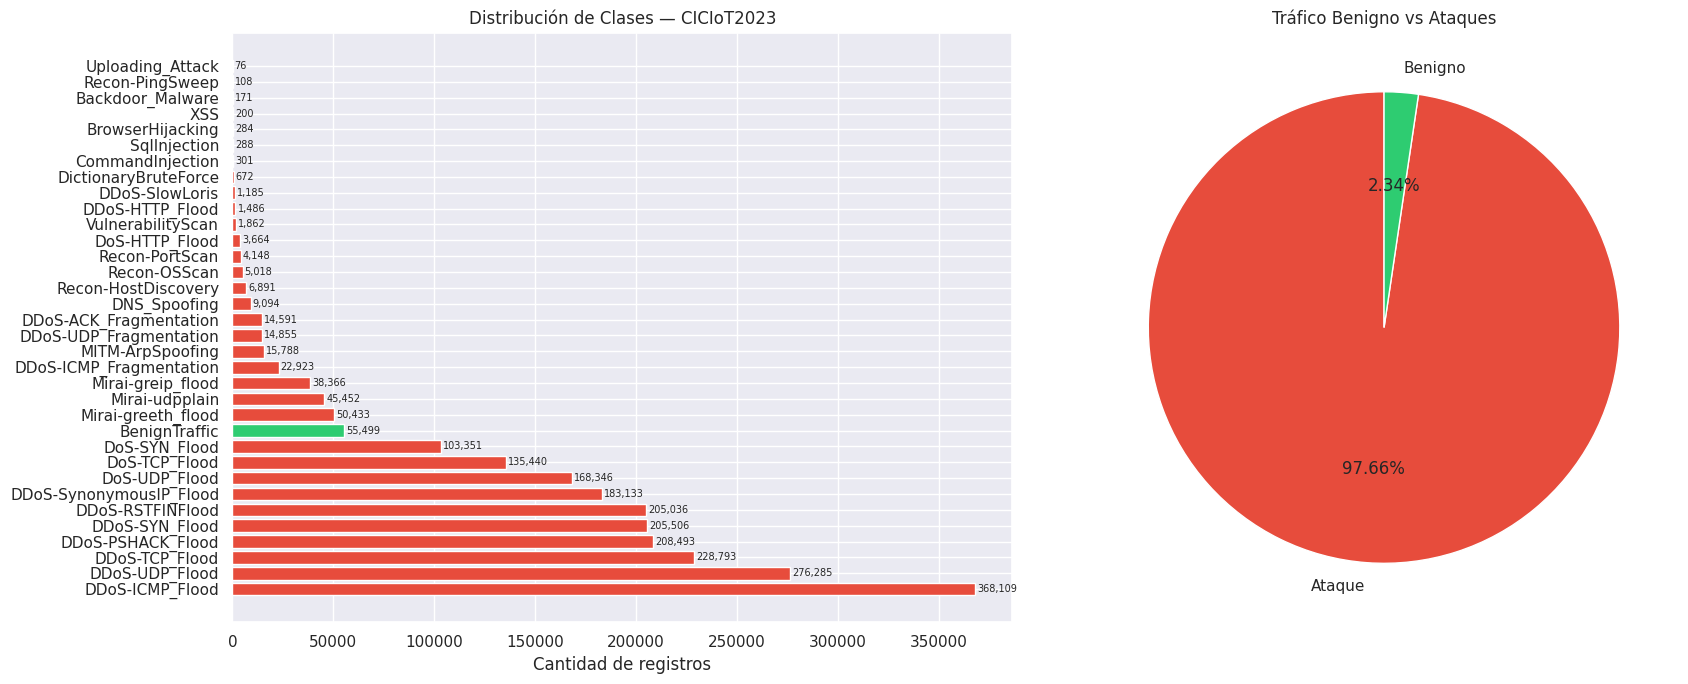


Total de clases únicas: 34
label
DDoS-ICMP_Flood            368109
DDoS-UDP_Flood             276285
DDoS-TCP_Flood             228793
DDoS-PSHACK_Flood          208493
DDoS-SYN_Flood             205506
DDoS-RSTFINFlood           205036
DDoS-SynonymousIP_Flood    183133
DoS-UDP_Flood              168346
DoS-TCP_Flood              135440
DoS-SYN_Flood              103351
BenignTraffic               55499
Mirai-greeth_flood          50433
Mirai-udpplain              45452
Mirai-greip_flood           38366
DDoS-ICMP_Fragmentation     22923
MITM-ArpSpoofing            15788
DDoS-UDP_Fragmentation      14855
DDoS-ACK_Fragmentation      14591
DNS_Spoofing                 9094
Recon-HostDiscovery          6891
Recon-OSScan                 5018
Recon-PortScan               4148
DoS-HTTP_Flood               3664
VulnerabilityScan            1862
DDoS-HTTP_Flood              1486
DDoS-SlowLoris               1185
DictionaryBruteForce          672
CommandInjection              301
SqlInjection  

In [ ]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barras horizontal — todas las clases
colors = ['#e74c3c' if x != 'BenignTraffic' else '#2ecc71'
          for x in label_counts.index]
axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Cantidad de registros')
axes[0].set_title('Distribución de Clases — CICIoT2023')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=7)

# Pie chart — Benigno vs Ataque
ataque_vs_benigno = df['label'].apply(
    lambda x: 'Benigno' if x == 'BenignTraffic' else 'Ataque'
).value_counts()
axes[1].pie(
    ataque_vs_benigno.values,
    labels=ataque_vs_benigno.index,
    autopct='%1.2f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90
)
axes[1].set_title('Tráfico Benigno vs Ataques')

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}distribucion_clases.png', bbox_inches='tight')
plt.show()

print(f'\nTotal de clases únicas: {label_counts.nunique()}')
print(label_counts)

*Distribución por categoría de ataque*

Se agrupa cada tipo de ataque en categorías de alto nivel para una visión más clara del panorama de amenazas

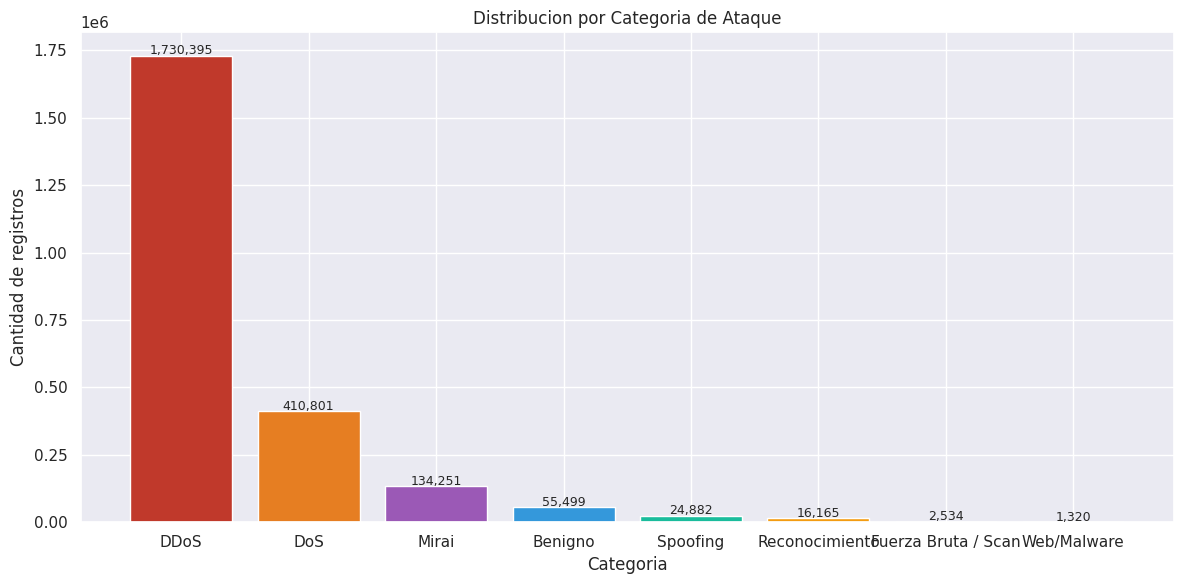

categoria
DDoS                   1730395
DoS                     410801
Mirai                   134251
Benigno                  55499
Spoofing                 24882
Reconocimiento           16165
Fuerza Bruta / Scan       2534
Web/Malware               1320
Name: count, dtype: int64


In [ ]:
def categorizar(label):
    if label == 'BenignTraffic':
        return 'Benigno'
    elif 'DDoS' in label:
        return 'DDoS'
    elif 'DoS' in label:
        return 'DoS'
    elif 'Mirai' in label:
        return 'Mirai'
    elif 'Recon' in label:
        return 'Reconocimiento'
    elif label in ['MITM-ArpSpoofing', 'DNS_Spoofing']:
        return 'Spoofing'
    elif label in ['BrowserHijacking', 'CommandInjection', 'SqlInjection', 'XSS', 'Backdoor_Malware', 'Uploading_Attack']:
        return 'Web/Malware'
    elif label in ['DictionaryBruteForce', 'VulnerabilityScan']:
        return 'Fuerza Bruta / Scan'
    else:
        return 'Otros'

df['categoria'] = df['label'].apply(categorizar)
cat_counts = df['categoria'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#c0392b','#e67e22','#9b59b6','#3498db','#1abc9c','#f39c12','#e74c3c','#2ecc71']
bars = ax.bar(cat_counts.index, cat_counts.values, color=colores[:len(cat_counts)])
ax.set_title("Distribucion por Categoria de Ataque")
ax.set_xlabel("Categoria")
ax.set_ylabel("Cantidad de registros")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{bar.get_height():,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("categorias_ataque.png", bbox_inches='tight')
plt.show()

print(cat_counts)

### 2.4 Análisis de Outliers (Método IQR)

Se utiliza el método del rango intercuartílico (IQR) para cuantificar la presencia de outliers en cada feature numérica. Un punto de datos se considera outlier si está fuera del rango `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

In [ ]:
features_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_resumen = []
for col in features_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    outlier_resumen.append({
        'feature': col,
        'outliers': outliers,
        'porcentaje': round(outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_resumen).sort_values('porcentaje', ascending=False)
print("TOP 15 FEATURES CON MAS OUTLIERS")
print("=" * 60)
print(outlier_df.head(15).to_string(index=False))

TOP 15 FEATURES CON MAS OUTLIERS
        feature  outliers  porcentaje
            Max    761669       32.06
            AVG    732250       30.82
       Tot size    732080       30.81
        Tot sum    728720       30.67
       Magnitue    728651       30.67
            Min    683563       28.77
       Duration    629666       26.50
  Header_Length    583952       24.58
      syn_count    567861       23.90
     Covariance    536274       22.57
      rst_count    533412       22.45
          Srate    523042       22.01
           Rate    523042       22.01
            UDP    504104       21.22
syn_flag_number    491632       20.69



**Hallazgo clave:** Features como `Max`, `AVG`, `Tot size`, `Tot sum` y `Magnitude` presentan más del 30% de sus valores como outliers. Esto justifica el uso de **RobustScaler** en el preprocesamiento, ya que es resistente a valores extremos al basarse en la mediana y el IQR.

### 2.5 Matriz de Correlación

La matriz de correlación permite identificar pares de features altamente correlacionadas, lo que puede indicar redundancia de información. Correlaciones elevadas (>0.8) entre features son candidatas a eliminación para reducir la dimensionalidad sin perder información.

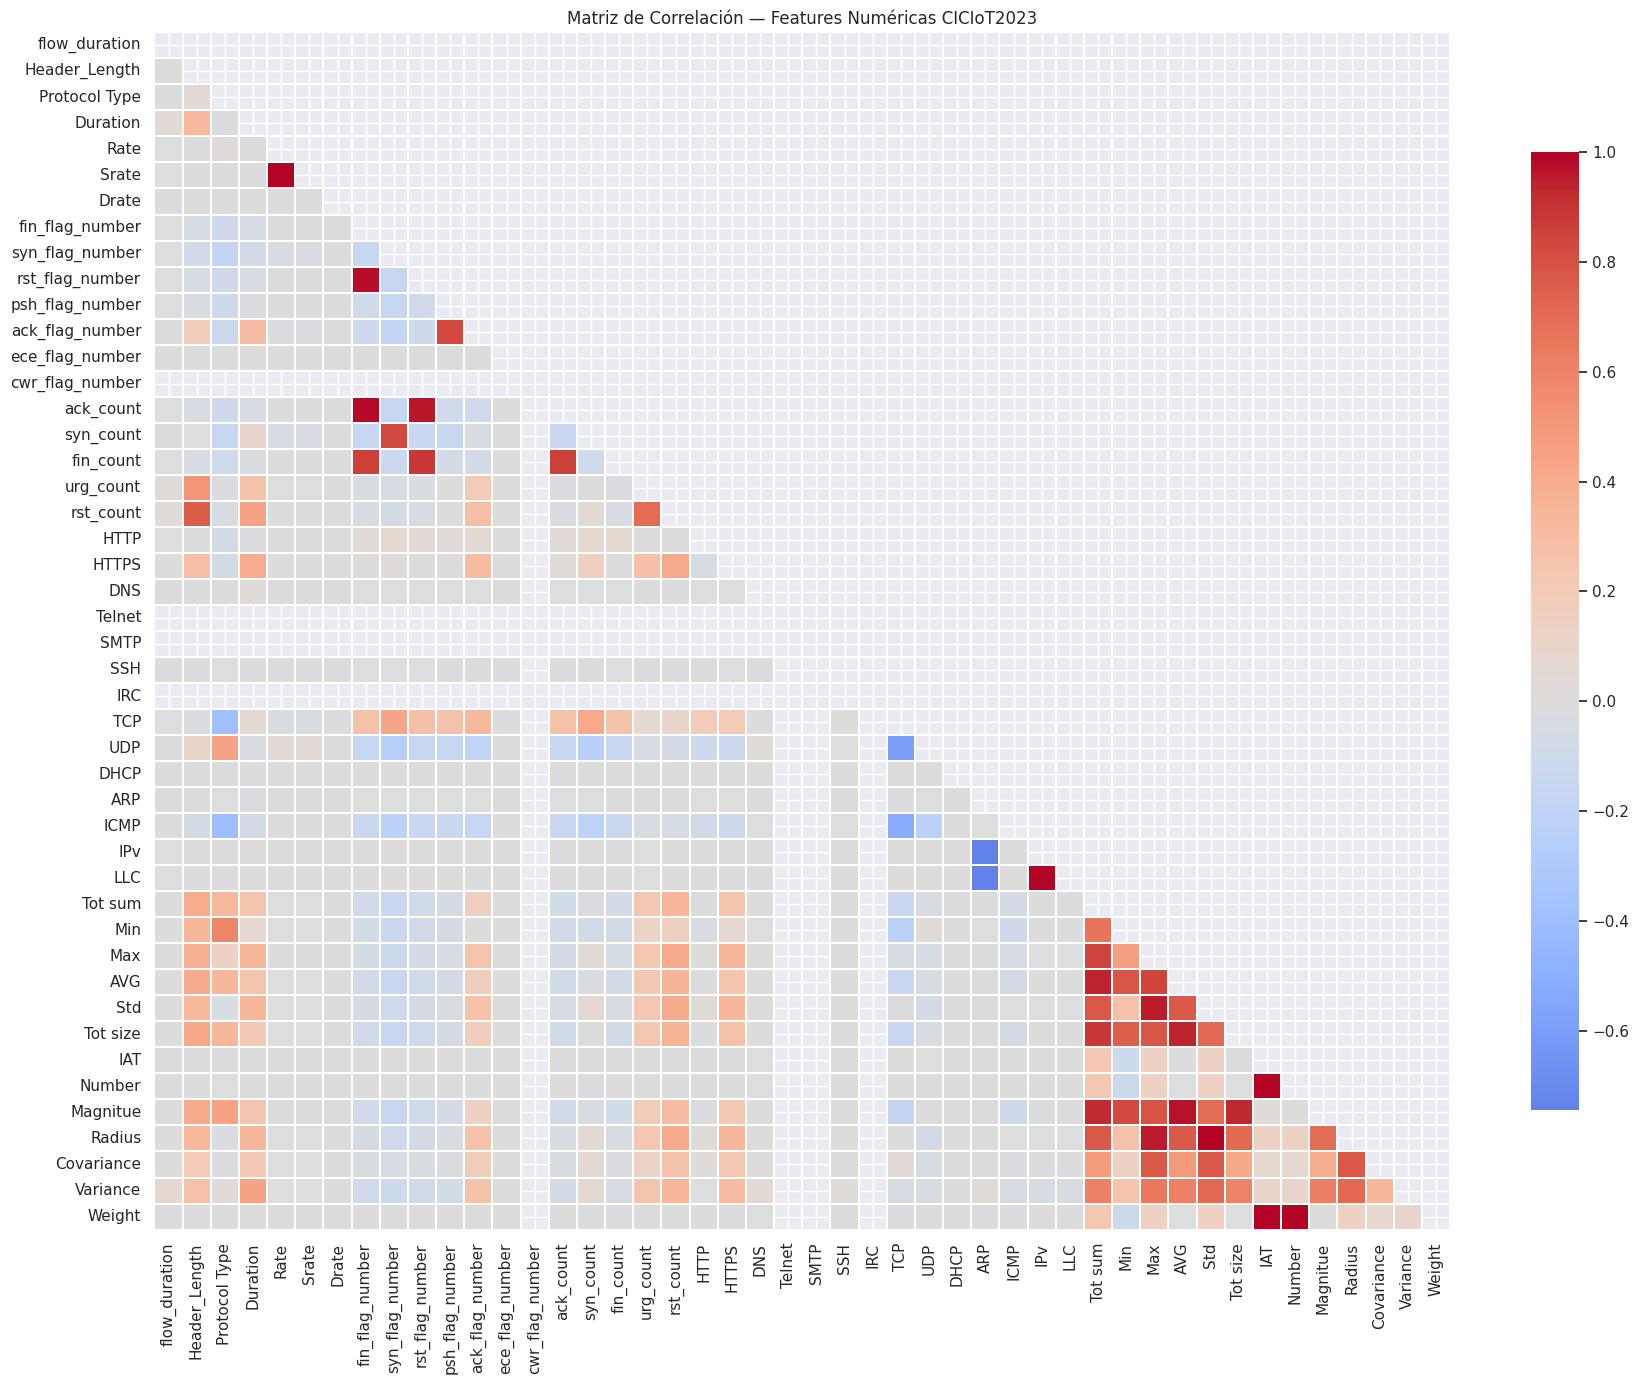

Pares con correlación >= 0.9:
      feature_1       feature_2  correlacion
           Rate           Srate       1.0000
            IPv             LLC       1.0000
            Std          Radius       1.0000
         Number          Weight       0.9996
            IAT          Weight       0.9974
            IAT          Number       0.9961
fin_flag_number       ack_count       0.9860
fin_flag_number rst_flag_number       0.9757
            AVG        Magnitue       0.9684
rst_flag_number       ack_count       0.9622
            Max             Std       0.9529
            Max          Radius       0.9529
            AVG        Tot size       0.9402
        Tot sum             AVG       0.9341
       Tot size        Magnitue       0.9291
        Tot sum        Magnitue       0.9226


In [ ]:
corr_matrix = df[features_numericas].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación — Features Numéricas CICIoT2023')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}correlacion.png', bbox_inches='tight')
plt.show()

# Identificar pares con correlación muy alta
umbral_corr = 0.90
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val >= umbral_corr:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlacion': round(val, 4)
            })

df_high_corr = pd.DataFrame(high_corr_pairs).sort_values(
    'correlacion', ascending=False)
print(f'Pares con correlación >= {umbral_corr}:')
print(df_high_corr.to_string(index=False))


**Observaciones principales:**
- `Rate` y `Srate` presentan correlación perfecta (~1.0), indicando que ambas miden prácticamente lo mismo
- `Min`, `Max`, `AVG`, `Tot size` y `Magnitude` forman un grupo correlacionado (features estadísticas de tamaño de paquete)
- `syn_flag_number` y `syn_count` muestran alta correlación entre sí
- La mayoría de features de protocolo (HTTP, HTTPS, DNS, etc.) tienen correlación baja entre sí, indicando poca redundancia en ese grupo

### 2.6 Distribución de Features Representativas

Se visualiza la distribución (limitada al percentil 99 para excluir outliers extremos) de 6 features relevantes. El patrón común es una distribución **fuertemente sesgada a la derecha**: la mayoría de los valores se concentran en un rango pequeño, con una cola larga hacia valores altos. Este comportamiento es típico en datos de tráfico de red.

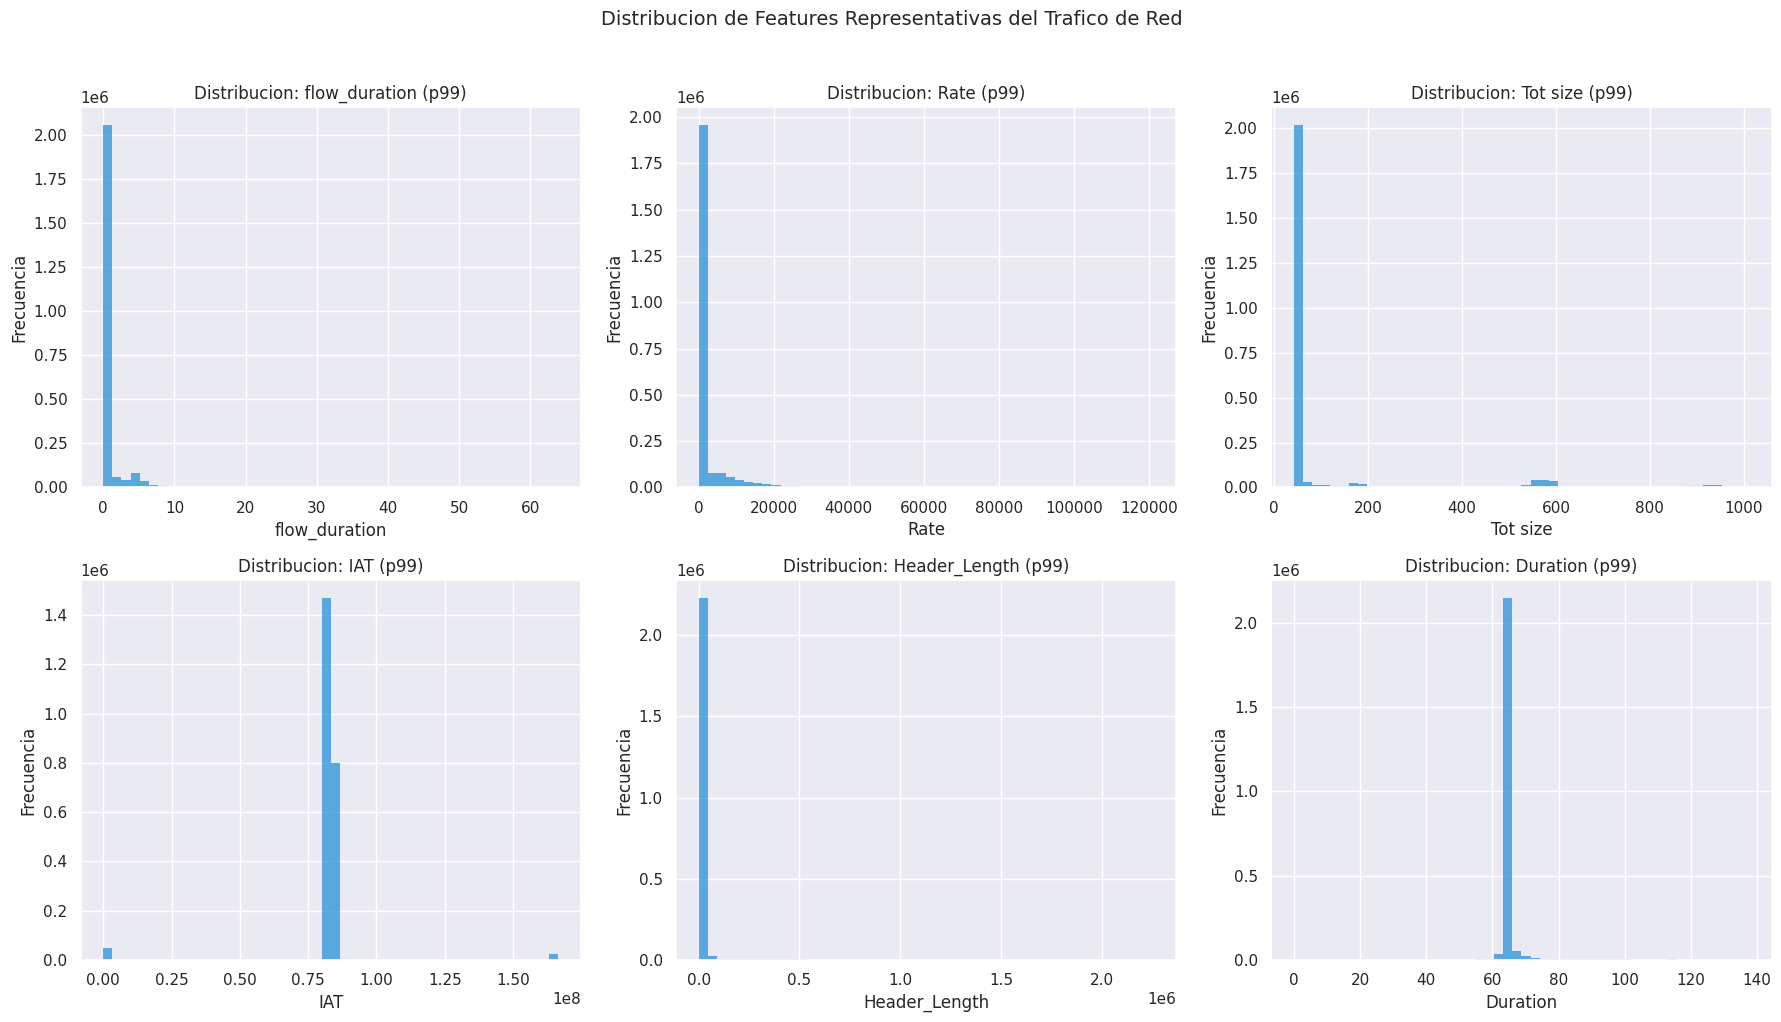

In [ ]:
top_features = ['flow_duration', 'Rate', 'Tot size', 'IAT', 'Header_Length', 'Duration']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    p99 = df[col].quantile(0.99)
    data = df[col][df[col] <= p99].dropna()
    axes[i].hist(data, bins=50, color='#3498db', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'Distribucion: {col} (p99)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle("Distribucion de Features Representativas del Trafico de Red", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("distribucion_features.png", bbox_inches='tight')
plt.show()

### 2.7 Resumen del EDA

| Hallazgo | Valor | Implicación |
|----------|-------|-------------|
| Valores nulos | 1 columna | tratar de no usar flow_duration |
| Duplicados | 2 filas (0.000%) | Eliminación trivial |
| Clases | 34 únicas | Clasificación multiclase compleja |
| Desbalance | 97.66% ataques vs 2.34% benigno | Requiere estrategia de balanceo |
| Outliers | Hasta ~31% en Max, AVG, Tot size | Usar RobustScaler |
| Correlaciones altas | Rate ≈ Srate (~1.0) | Redundancia identificada |
| Distribuciones | Sesgadas a la derecha en la mayoría | Confirma necesidad de escalado robusto |

---
# SECCIÓN 3 — Preprocesamiento de Datos

En base a los hallazgos del EDA, se aplica el siguiente pipeline de preprocesamiento:

1. **Eliminación de duplicados** — Se eliminan las 2 filas duplicadas identificadas
2. **Codificación de etiquetas** — `LabelEncoder` transforma las 34 clases de texto a enteros (0–33)
3. **Escalado robusto** — `RobustScaler` normaliza las features usando mediana e IQR, resistente a outliers
4. **Balanceo de clases** — Estrategia combinada:
   - **Undersampling**: limita clases mayoritarias a máximo 100,000 muestras
   - **Oversampling**: eleva clases minoritarias a mínimo 1,000 muestras
5. **División train/test** — Split 80/20 estratificado para preservar la distribución de clases

*Cargar 2M de filas para preprocesamiento* 

In [ ]:
df_pre = pd.read_csv(
    f'{DRIVE_PATH}ciciot2023_consolidado.csv',
    low_memory=False,
    nrows=2_000_000
)
print(f'Shape: {df_pre.shape}')
print(f'Clases únicas: {df_pre["label"].nunique()}')
print(df_pre['label'].value_counts())

Shape: (2000000, 47)
Clases únicas: 34
label
DDoS-ICMP_Flood            309969
DDoS-UDP_Flood             232788
DDoS-TCP_Flood             192267
DDoS-PSHACK_Flood          175577
DDoS-SYN_Flood             173165
DDoS-RSTFINFlood           172590
DDoS-SynonymousIP_Flood    154093
DoS-UDP_Flood              141568
DoS-TCP_Flood              114159
DoS-SYN_Flood               86865
BenignTraffic               46638
Mirai-greeth_flood          42514
Mirai-udpplain              38276
Mirai-greip_flood           32299
DDoS-ICMP_Fragmentation     19277
MITM-ArpSpoofing            13256
DDoS-UDP_Fragmentation      12549
DDoS-ACK_Fragmentation      12264
DNS_Spoofing                 7665
Recon-HostDiscovery          5808
Recon-OSScan                 4228
Recon-PortScan               3477
DoS-HTTP_Flood               3068
VulnerabilityScan            1572
DDoS-HTTP_Flood              1259
DDoS-SlowLoris               1034
DictionaryBruteForce          565
CommandInjection              259
Sql

Paso 1: Eliminar duplicados y separar features/label

In [ ]:
df_pre = df_pre.drop_duplicates()
print(f'Shape después de eliminar duplicados: {df_pre.shape}')

X = df_pre.drop(columns=['label'])
y = df_pre['label']

print(f'Features: {X.shape[1]}')
print(f'Clases  : {y.nunique()}')

Shape después de eliminar duplicados: (2000000, 47)
Features: 46
Clases  : 34


Paso 2: Codificación de etiquetas con label encoder

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Mapeo de clases (índice → nombre):')
for i, clase in enumerate(le.classes_):
    print(f'  {i:2d} → {clase}')

Mapeo de clases (índice → nombre):
   0 → Backdoor_Malware
   1 → BenignTraffic
   2 → BrowserHijacking
   3 → CommandInjection
   4 → DDoS-ACK_Fragmentation
   5 → DDoS-HTTP_Flood
   6 → DDoS-ICMP_Flood
   7 → DDoS-ICMP_Fragmentation
   8 → DDoS-PSHACK_Flood
   9 → DDoS-RSTFINFlood
  10 → DDoS-SYN_Flood
  11 → DDoS-SlowLoris
  12 → DDoS-SynonymousIP_Flood
  13 → DDoS-TCP_Flood
  14 → DDoS-UDP_Flood
  15 → DDoS-UDP_Fragmentation
  16 → DNS_Spoofing
  17 → DictionaryBruteForce
  18 → DoS-HTTP_Flood
  19 → DoS-SYN_Flood
  20 → DoS-TCP_Flood
  21 → DoS-UDP_Flood
  22 → MITM-ArpSpoofing
  23 → Mirai-greeth_flood
  24 → Mirai-greip_flood
  25 → Mirai-udpplain
  26 → Recon-HostDiscovery
  27 → Recon-OSScan
  28 → Recon-PingSweep
  29 → Recon-PortScan
  30 → SqlInjection
  31 → Uploading_Attack
  32 → VulnerabilityScan
  33 → XSS


Paso 3: Aplicar RobustScaler

Se eligió RobustScaler porque es resistente a outliers (usa mediana e IQR en lugar de media y desviación estándar)

In [ ]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("RobustScaler aplicado correctamente")
print(f"Shape: {X_scaled.shape}")
print(f"\nEstadisticas post-escalado (primeras 5 features):")
print(X_scaled.iloc[:, :5].describe().round(4))

RobustScaler aplicado correctamente
Shape: (2000000, 46)

Estadisticas post-escalado (primeras 5 features):
       flow_duration  Header_Length  Protocol Type      Duration          Rate
count   1.999999e+06   2.000000e+06   2.000000e+06  2.000000e+06  2.000000e+06
mean    5.339440e+01   3.099777e+02   3.576000e-01  2.326700e+00  7.593260e+01
std     2.551679e+03   1.867939e+03   1.043300e+00  1.390460e+01  8.305136e+02
min     0.000000e+00  -2.188000e-01  -6.993000e-01 -6.400000e+01 -1.354000e-01
25%     0.000000e+00   0.000000e+00   0.000000e+00  0.000000e+00 -1.175000e-01
50%     0.000000e+00   0.000000e+00   0.000000e+00  0.000000e+00  0.000000e+00
75%     1.000000e+00   1.000000e+00   1.000000e+00  0.000000e+00  8.825000e-01
max     8.923960e+05   3.988255e+04   4.778600e+00  1.910000e+02  7.188821e+04


Paso 4: Estrategía de manejo de desbalance

Para el balanceo de Clases hicimos Under + Oversampling para manejar el desbalance severo



In [ ]:
conteo_original = Counter(y_encoded)
print("Distribucion original (top 10):")
for clase, count in sorted(conteo_original.items(), key=lambda x: -x[1])[:10]:
    print(f"  {le.classes_[clase]}: {count:,}")

LIMITE_MAXIMO = 100000
LIMITE_MINIMO = 1000

under_strategy = {k: min(v, LIMITE_MAXIMO) for k, v in conteo_original.items()}
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_under, y_under = rus.fit_resample(X_scaled, y_encoded)

conteo_under = Counter(y_under)
print(f"\nShape tras undersampling: {X_under.shape}")

over_strategy = {k: max(v, LIMITE_MINIMO) for k, v in conteo_under.items()}
ros = RandomOverSampler(sampling_strategy=over_strategy, random_state=42)
X_bal, y_bal = ros.fit_resample(X_under, y_under)

print(f"Shape tras oversampling: {X_bal.shape}")
print(f"\nDistribucion final:")
conteo_final = Counter(y_bal)
for clase, count in sorted(conteo_final.items(), key=lambda x: -x[1]):
    print(f"  {le.classes_[clase]}: {count:,}")

Distribucion original (top 10):
  DDoS-ICMP_Flood: 309,969
  DDoS-UDP_Flood: 232,788
  DDoS-TCP_Flood: 192,267
  DDoS-PSHACK_Flood: 175,577
  DDoS-SYN_Flood: 173,165
  DDoS-RSTFINFlood: 172,590
  DDoS-SynonymousIP_Flood: 154,093
  DoS-UDP_Flood: 141,568
  DoS-TCP_Flood: 114,159
  DoS-SYN_Flood: 86,865

Shape tras undersampling: (1233824, 46)
Shape tras oversampling: (1240049, 46)

Distribucion final:
  DDoS-ICMP_Flood: 100,000
  DDoS-PSHACK_Flood: 100,000
  DDoS-RSTFINFlood: 100,000
  DDoS-SYN_Flood: 100,000
  DDoS-SynonymousIP_Flood: 100,000
  DDoS-TCP_Flood: 100,000
  DDoS-UDP_Flood: 100,000
  DoS-TCP_Flood: 100,000
  DoS-UDP_Flood: 100,000
  DoS-SYN_Flood: 86,865
  BenignTraffic: 46,638
  Mirai-greeth_flood: 42,514
  Mirai-udpplain: 38,276
  Mirai-greip_flood: 32,299
  DDoS-ICMP_Fragmentation: 19,277
  MITM-ArpSpoofing: 13,256
  DDoS-UDP_Fragmentation: 12,549
  DDoS-ACK_Fragmentation: 12,264
  DNS_Spoofing: 7,665
  Recon-HostDiscovery: 5,808
  Recon-OSScan: 4,228
  Recon-PortScan: 3

Paso 5: Separación de train/test  (80/20)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {Counter(y_train)}")

X_train: (992039, 46)
X_test:  (248010, 46)
y_train: Counter({np.int64(13): 80000, np.int64(21): 80000, np.int64(10): 80000, np.int64(6): 80000, np.int64(14): 80000, np.int64(12): 80000, np.int64(9): 80000, np.int64(8): 80000, np.int64(20): 80000, np.int64(19): 69492, np.int64(1): 37310, np.int64(23): 34011, np.int64(25): 30621, np.int64(24): 25839, np.int64(7): 15422, np.int64(22): 10605, np.int64(15): 10039, np.int64(4): 9811, np.int64(16): 6132, np.int64(26): 4646, np.int64(27): 3382, np.int64(29): 2782, np.int64(18): 2455, np.int64(32): 1258, np.int64(5): 1007, np.int64(11): 827, np.int64(33): 800, np.int64(17): 800, np.int64(3): 800, np.int64(31): 800, np.int64(0): 800, np.int64(28): 800, np.int64(30): 800, np.int64(2): 800})


*Guardar datasets procesados en Drive*

In [ ]:
np.save(f'{DRIVE_PATH}X_train.npy', X_train)
np.save(f'{DRIVE_PATH}X_test.npy',  X_test)
np.save(f'{DRIVE_PATH}y_train.npy', y_train)
np.save(f'{DRIVE_PATH}y_test.npy',  y_test)
np.save(f'{DRIVE_PATH}feature_names.npy', np.array(X.columns.tolist()))

with open(f'{DRIVE_PATH}label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open(f'{DRIVE_PATH}robust_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Archivos guardados en Drive:")
print("  X_train.npy, X_test.npy")
print("  y_train.npy, y_test.npy")
print("  feature_names.npy")
print("  label_encoder.pkl")
print("  robust_scaler.pkl")

Archivos guardados en Drive:
  X_train.npy, X_test.npy
  y_train.npy, y_test.npy
  feature_names.npy
  label_encoder.pkl
  robust_scaler.pkl


---
# SECCIÓN 4 — Selección de Características con Random Forest

## 4.1 Random Forest Preliminar para Feature Importance

Se entrena un **Random Forest preliminar** cuyo único propósito es obtener el ranking de importancia de las 46 features originales. Este modelo no es el modelo final de clasificación, sino una herramienta de diagnóstico para la selección de features.

**Criterio de corte:** Se eliminan las features con importancia < 0.001, ya que su contribución al modelo es negligible y su inclusión solo añade ruido y costo computacional.

### Parámetros del Random Forest
- `n_estimators=100`: 100 árboles para un ranking estable
- `max_depth=20`: profundidad suficiente para capturar interacciones complejas
- `min_samples_leaf=5`: evita overfitting en hojas muy pequeñas
- `n_jobs=-1`: paralelización completa

*Cargar datos procesados para selección de features*

Si ya corrieron lo anterior, posiblemente lo tengan ya en memoria, entonces no es necesario cargarlos, pero si no, corran la siguiente celda

In [ ]:
X_train      = np.load(f'{DRIVE_PATH}X_train.npy')
X_test       = np.load(f'{DRIVE_PATH}X_test.npy')
y_train      = np.load(f'{DRIVE_PATH}y_train.npy')
y_test       = np.load(f'{DRIVE_PATH}y_test.npy')
feature_names = np.load(f'{DRIVE_PATH}feature_names.npy',
                        allow_pickle=True)

with open(f'{DRIVE_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'Features: {feature_names.tolist()}')

X_train: (992039, 46)
X_test : (248010, 46)
Features: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


**Random Foresst preliminar**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf.fit(X_train, y_train)
print("Entrenamiento completado")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  2.4min


Entrenamiento completado


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.1min finished


*Extraer y visualizar feature importance*

In [ ]:
importancias = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Ranking completo de importancia:")
print(importancias.to_string())

Ranking completo de importancia:
            feature    importance
0               IAT  2.520369e-01
1         syn_count  5.883386e-02
2          Magnitue  4.947251e-02
3   psh_flag_number  4.316355e-02
4     Header_Length  4.240044e-02
5               AVG  4.162516e-02
6     Protocol Type  3.852509e-02
7               Min  3.825298e-02
8          Tot size  3.684477e-02
9   syn_flag_number  3.612696e-02
10  fin_flag_number  3.141277e-02
11              Max  3.088148e-02
12          Tot sum  2.702766e-02
13    flow_duration  2.634478e-02
14        fin_count  2.623827e-02
15        rst_count  2.525295e-02
16              UDP  2.263513e-02
17        urg_count  2.000832e-02
18        ack_count  1.962956e-02
19            Srate  1.949174e-02
20             Rate  1.893207e-02
21  rst_flag_number  1.645610e-02
22              TCP  1.559719e-02
23         Variance  1.064109e-02
24  ack_flag_number  9.224409e-03
25             ICMP  9.059690e-03
26       Covariance  6.947349e-03
27           Ra

*Visualizar Importancia*

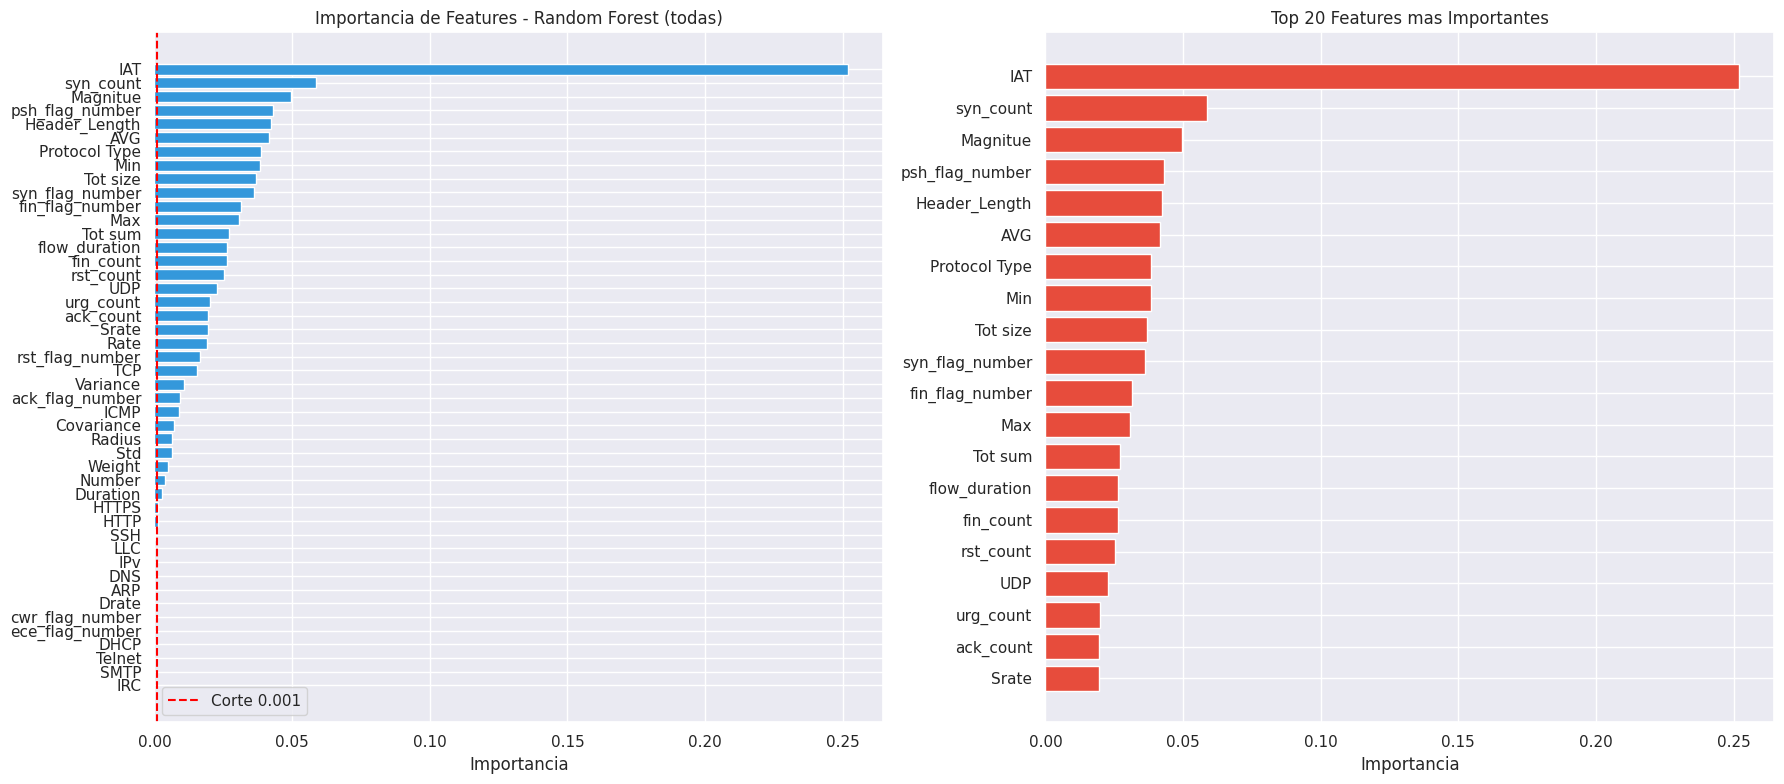

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# todas las features
axes[0].barh(importancias['feature'][::-1], importancias['importance'][::-1], color='#3498db')
axes[0].set_title("Importancia de Features - Random Forest (todas)")
axes[0].set_xlabel("Importancia")
axes[0].axvline(x=0.001, color='red', linestyle='--', label='Corte 0.001')
axes[0].legend()

# top 20
top20 = importancias.head(20)
axes[1].barh(top20['feature'][::-1], top20['importance'][::-1], color='#e74c3c')
axes[1].set_title("Top 20 Features mas Importantes")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/feature_importance.png", bbox_inches='tight')
plt.show()

*Aplicar Corte y seleccionar features*

In [ ]:
CORTE = 0.001

features_seleccionadas = importancias[importancias['importance'] >= CORTE]['feature'].tolist()
features_eliminadas = importancias[importancias['importance'] < CORTE]['feature'].tolist()

print(f"Features seleccionadas ({len(features_seleccionadas)}): {features_seleccionadas}")
print(f"\nFeatures eliminadas ({len(features_eliminadas)}): {features_eliminadas}")

idx_seleccionadas = [list(feature_names).index(f) for f in features_seleccionadas]
X_train_sel = X_train[:, idx_seleccionadas]
X_test_sel  = X_test[:, idx_seleccionadas]

print(f"\nX_train_sel: {X_train_sel.shape}")
print(f"X_test_sel:  {X_test_sel.shape}")

Features seleccionadas (34): ['IAT', 'syn_count', 'Magnitue', 'psh_flag_number', 'Header_Length', 'AVG', 'Protocol Type', 'Min', 'Tot size', 'syn_flag_number', 'fin_flag_number', 'Max', 'Tot sum', 'flow_duration', 'fin_count', 'rst_count', 'UDP', 'urg_count', 'ack_count', 'Srate', 'Rate', 'rst_flag_number', 'TCP', 'Variance', 'ack_flag_number', 'ICMP', 'Covariance', 'Radius', 'Std', 'Weight', 'Number', 'Duration', 'HTTPS', 'HTTP']

Features eliminadas (12): ['SSH', 'LLC', 'IPv', 'DNS', 'ARP', 'Drate', 'cwr_flag_number', 'ece_flag_number', 'DHCP', 'Telnet', 'SMTP', 'IRC']

X_train_sel: (992039, 34)
X_test_sel:  (248010, 34)


*Guardar Subconjunto seleccionado y modelo RF*

In [ ]:
np.save(f'{DRIVE_PATH}X_train_sel.npy', X_train_sel)
np.save(f'{DRIVE_PATH}X_test_sel.npy',  X_test_sel)
np.save(f'{DRIVE_PATH}features_seleccionadas.npy', np.array(features_seleccionadas))

with open(f'{DRIVE_PATH}rf_preliminar.pkl', 'wb') as f:
    pickle.dump(rf, f)

print('Archivos guardados en Drive:')

Archivos guardados en Drive:


**JUSTIFICACION DEL CORTE DE FEATURES**

* Corte aplicado     : importance >= 0.001
* Features originales: 46
* Features retenidas : 34
* Features eliminadas: 12
* Reduccion          : 26.1%

Features eliminadas por importancia < 0.001:
  - SSH: 5.88e-05
  - DNS: 1.34e-05
  - LLC: 1.25e-05
  - ARP: 1.02e-05
  - IPv: 9.88e-06
  - Drate: 7.29e-13
  - cwr_flag_number: 0.00e+00
  - ece_flag_number: 0.00e+00
  - DHCP: 0.00e+00
  - Telnet: 0.00e+00
  - SMTP: 0.00e+00
  - IRC: 0.00e+00

La feature mas importante es IAT con 0.2567

Las primeras 10 features acumulan el 63.2% de la importancia total
---
# SECCIÓN 5 — Validación con SHAP Values

## 5.1 ¿Por qué SHAP?

La **Feature Importance de Random Forest** mide cuánto contribuye cada feature a la reducción de impureza promedio en todos los árboles. Sin embargo, este método tiene limitaciones conocidas:

- **Sesgo hacia features de alta cardinalidad**: features con muchos valores únicos tienden a obtener importancias infladas
- **No captura interacciones**: no distingue si una feature es importante por sí sola o solo en combinación con otras
- **No es aditivo**: los valores no suman a 1 de forma interpretable

**SHAP** (SHapley Additive exPlanations) es un método basado en la teoría de juegos cooperativos que asigna a cada feature una contribución marginal promedio sobre todas las posibles combinaciones de features. Sus ventajas son:

- **Consistencia**: si una feature se vuelve más importante, su valor SHAP no puede decrecer
- **Interpretabilidad local y global**: permite ver tanto la importancia global como el impacto por instancia
- **Detecta interacciones**: captura el efecto real de cada feature, incluyendo interacciones con otras

## 5.2 Estrategia de muestreo

El RF original tiene **778,396 nodos** distribuidos en 100 árboles × 34 clases. Inicializar `TreeExplainer` sobre este modelo requeriría horas de cómputo porque SHAP debe parsear la estructura interna de cada nodo para calcular las contribuciones exactas.

La solución estándar documentada en la librería SHAP es entrenar un **modelo proxy más pequeño** sobre una muestra representativa de los mismos datos. El ranking de importancia de features es estable entre RF de distinto tamaño entrenados sobre los mismos datos, siempre que la muestra sea estratificada y suficientemente representativa. El objetivo no es replicar el modelo de producción sino obtener un ranking de importancia confiable para comparación.

Se utilizan:
- **10,000 muestras estratificadas** para entrenar el RF proxy
- **RF proxy**: 15 árboles, max_depth=10 (~4,235 nodos total)
- **2,000 muestras estratificadas** para calcular SHAP values


In [12]:
X_train       = np.load(f'{DRIVE_PATH}X_train.npy')
X_test        = np.load(f'{DRIVE_PATH}X_test.npy')
y_train       = np.load(f'{DRIVE_PATH}y_train.npy')
y_test        = np.load(f'{DRIVE_PATH}y_test.npy')
feature_names = np.load(f'{DRIVE_PATH}feature_names.npy', allow_pickle=True)
features_sel  = np.load(f'{DRIVE_PATH}features_seleccionadas.npy', allow_pickle=True)
X_train_sel   = np.load(f'{DRIVE_PATH}X_train_sel.npy')
X_test_sel    = np.load(f'{DRIVE_PATH}X_test_sel.npy')

with open(f'{DRIVE_PATH}rf_preliminar.pkl', 'rb') as f:
    rf = pickle.load(f)
with open(f'{DRIVE_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print(f'X_train      : {X_train.shape}')
print(f'X_train_sel  : {X_train_sel.shape}')
print(f'feature_names: {len(feature_names)} features')
print(f'features_sel : {len(features_sel)} features seleccionadas')
print(f'RF original  : {rf.n_estimators} árboles, max_depth={rf.max_depth}, {rf.n_classes_} clases')

total_nodos = sum(t.tree_.node_count for t in rf.estimators_)
print(f'Total nodos RF: {total_nodos:,}')

X_train      : (992039, 46)
X_train_sel  : (992039, 34)
feature_names: 46 features
features_sel : 34 features seleccionadas
RF original  : 100 árboles, max_depth=20, 34 clases
Total nodos RF: 778,396


*Muestra estratificada para shap*

In [13]:
SHAP_SAMPLE_SIZE = 2000

indices_shap = resample(
    np.arange(len(X_train)),
    n_samples=SHAP_SAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)
X_shap = X_train[indices_shap]
y_shap = y_train[indices_shap]

print(f'Muestra SHAP: {X_shap.shape}')
print(f'Distribución de clases en muestra: {Counter(y_shap)}')

Muestra SHAP: (2000, 46)
Distribución de clases en muestra: Counter({np.int64(9): 161, np.int64(12): 161, np.int64(6): 161, np.int64(10): 161, np.int64(13): 161, np.int64(8): 161, np.int64(21): 161, np.int64(20): 161, np.int64(14): 161, np.int64(19): 140, np.int64(1): 75, np.int64(23): 69, np.int64(25): 62, np.int64(24): 52, np.int64(7): 31, np.int64(22): 21, np.int64(4): 20, np.int64(15): 20, np.int64(16): 12, np.int64(26): 9, np.int64(27): 7, np.int64(29): 6, np.int64(18): 5, np.int64(3): 2, np.int64(17): 2, np.int64(0): 2, np.int64(30): 2, np.int64(28): 2, np.int64(31): 2, np.int64(32): 2, np.int64(5): 2, np.int64(33): 2, np.int64(11): 2, np.int64(2): 2})


*Emtrenar RF Proxy para shap*
- RF pequeño sobre muestra representativa de los mismos datos.
- El ranking de features es estable entre RF de distinto tamaño entrenados sobre los mismos datos (mismo dominio, mismas clases).

In [14]:
idx_proxy = resample(
    np.arange(len(X_train)),
    n_samples=10000,
    stratify=y_train,
    random_state=42
)

rf_for_shap = RandomForestClassifier(
    n_estimators=15,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
rf_for_shap.fit(X_train[idx_proxy], y_train[idx_proxy])

total_nodos_proxy = sum(t.tree_.node_count for t in rf_for_shap.estimators_)
print(f'RF proxy entrenado.')
print(f'  Nodos RF original : {total_nodos:,}')
print(f'  Nodos RF proxy    : {total_nodos_proxy:,}')
print(f'  Reducción         : {(1 - total_nodos_proxy/total_nodos)*100:.1f}%')

RF proxy entrenado.
  Nodos RF original : 778,396
  Nodos RF proxy    : 4,235
  Reducción         : 99.5%


*Calcular shap values*

TreeExplainer es el método exacto para modelos basados en árboles. feature_perturbation='tree_path_dependent', evita la necesidad de un background dataset y acelera el cálculo. shap_values shape resultante: (n_muestras, n_features, n_clases) = (2000, 46, 34)

In [16]:
print('Inicializando TreeExplainer...')
explainer = shap.TreeExplainer(
    rf_for_shap,
    feature_perturbation='tree_path_dependent'
)
print('TreeExplainer inicializado')

print('Calculando SHAP values...')
shap_values = explainer.shap_values(X_shap, check_additivity=False)
print(f'shap_values shape: {np.array(shap_values).shape}')

# Importancia global: promedio del |shap| sobre muestras y clases
# (2000, 46, 34) → mean axis(0,2) → (46,)
shap_importance = np.abs(shap_values).mean(axis=(0, 2))
print(f'shap_importance shape: {shap_importance.shape}')

shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)
shap_df['shap_rank'] = range(1, len(shap_df) + 1)

print('\nRanking SHAP completo:')
print(shap_df.to_string())

Inicializando TreeExplainer...
TreeExplainer inicializado
Calculando SHAP values...
shap_values shape: (2000, 46, 34)
shap_importance shape: (46,)

Ranking SHAP completo:
            feature  shap_importance  shap_rank
0   syn_flag_number         0.011991          1
1               IAT         0.010125          2
2               TCP         0.004352          3
3               UDP         0.004246          4
4     Protocol Type         0.003973          5
5         syn_count         0.003963          6
6           Tot sum         0.003725          7
7               Max         0.003574          8
8          Magnitue         0.003512          9
9               AVG         0.003280         10
10    flow_duration         0.003240         11
11    Header_Length         0.003190         12
12              Min         0.003104         13
13  ack_flag_number         0.002713         14
14  fin_flag_number         0.002457         15
15  rst_flag_number         0.002455         16
16        urg

### 5.3 Comparación RF Feature Importance vs SHAP

Se comparan los rankings obtenidos por ambos métodos para identificar:
- **Coincidencias**: features que ambos métodos consideran importantes → alta confianza en su relevancia
- **Discrepancias**: features que un método valora pero el otro no → requieren análisis adicional
- **Consenso final**: features validadas por ambos métodos → conjunto base para el dataset final

In [18]:
importancias_rf = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)
importancias_rf['rf_rank'] = range(1, len(importancias_rf) + 1)

comparacion = importancias_rf.merge(
    shap_df[['feature', 'shap_importance', 'shap_rank']],
    on='feature'
)
comparacion['diff_rank'] = abs(
    comparacion['rf_rank'] - comparacion['shap_rank']
)
comparacion = comparacion.sort_values('rf_rank').reset_index(drop=True)

print('=== COMPARACIÓN RF IMPORTANCE vs SHAP ===')
print(comparacion[['feature', 'rf_rank', 'shap_rank',
                   'diff_rank']].to_string(index=False))

print(f'\nDiferencia promedio de ranking : {comparacion["diff_rank"].mean():.2f} posiciones')
print(f'Features con diferencia <= 3   : {(comparacion["diff_rank"] <= 3).sum()}')
print(f'Features con diferencia > 10   : {(comparacion["diff_rank"] > 10).sum()}')

# Coincidencias en Top 10
top10_rf   = set(importancias_rf.head(10)['feature'])
top10_shap = set(shap_df.head(10)['feature'])
print(f'\nCoincidencias en Top 10: {len(top10_rf & top10_shap)}/10')
print(f'  Coinciden  : {sorted(top10_rf & top10_shap)}')
print(f'  Solo en RF : {sorted(top10_rf - top10_shap)}')
print(f'  Solo SHAP  : {sorted(top10_shap - top10_rf)}')

comparacion.to_csv(f'{DRIVE_PATH}shap_vs_rf_ranking.csv', index=False)
print('\n shap_vs_rf_ranking.csv guardado en Drive')

=== COMPARACIÓN RF IMPORTANCE vs SHAP ===
        feature  rf_rank  shap_rank  diff_rank
            IAT        1          2          1
      syn_count        2          6          4
       Magnitue        3          9          6
psh_flag_number        4         20         16
  Header_Length        5         12          7
            AVG        6         10          4
  Protocol Type        7          5          2
            Min        8         13          5
       Tot size        9         21         12
syn_flag_number       10          1          9
fin_flag_number       11         15          4
            Max       12          8          4
        Tot sum       13          7          6
  flow_duration       14         11          3
      fin_count       15         23          8
      rst_count       16         18          2
            UDP       17          4         13
      urg_count       18         17          1
      ack_count       19         19          0
          Srate   

*Visualización de comparación*

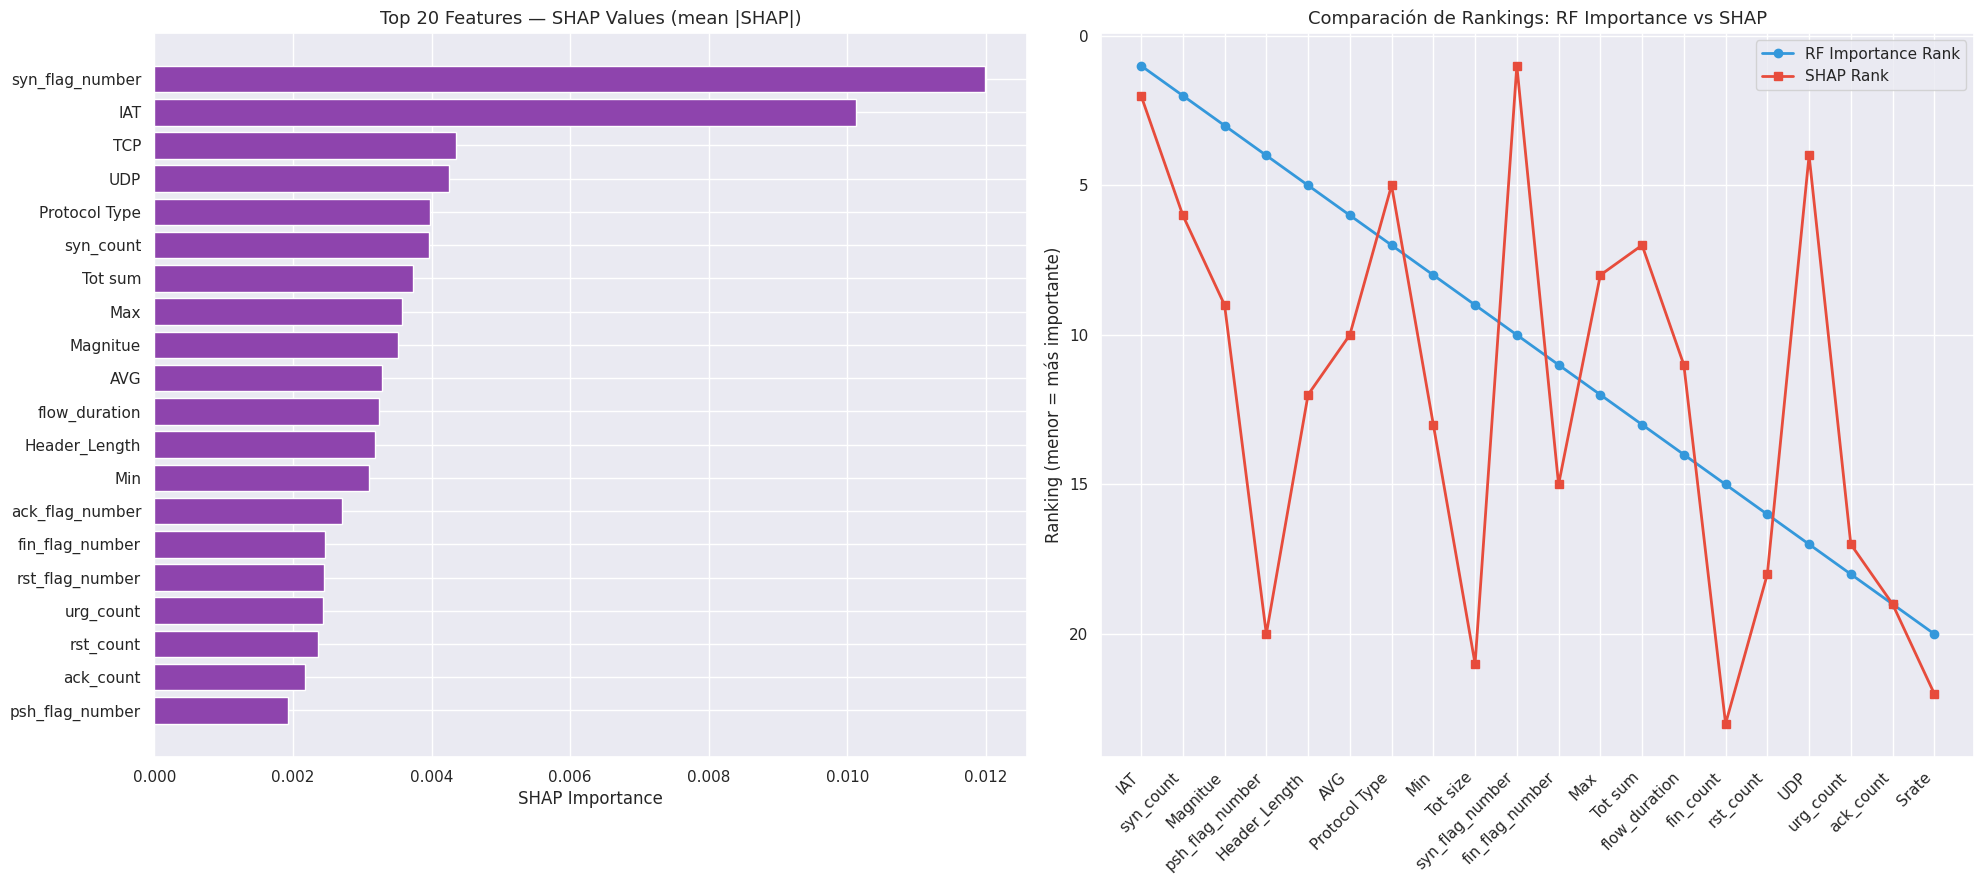

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Top 20 SHAP
top20_shap = shap_df.head(20)
axes[0].barh(top20_shap['feature'][::-1],
             top20_shap['shap_importance'][::-1], color='#8e44ad')
axes[0].set_title('Top 20 Features — SHAP Values (mean |SHAP|)', fontsize=13)
axes[0].set_xlabel('SHAP Importance')

# Comparación de rankings RF vs SHAP
top_cmp = comparacion.head(20).reset_index(drop=True)
x = range(len(top_cmp))
axes[1].plot(x, top_cmp['rf_rank'],   'o-',
             color='#3498db', label='RF Importance Rank', linewidth=2)
axes[1].plot(x, top_cmp['shap_rank'], 's-',
             color='#e74c3c', label='SHAP Rank',          linewidth=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_cmp['feature'], rotation=45, ha='right')
axes[1].set_title('Comparación de Rankings: RF Importance vs SHAP', fontsize=13)
axes[1].set_ylabel('Ranking (menor = más importante)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}shap_vs_rf_comparison.png', bbox_inches='tight')
plt.show()

**Decisión sobre el conjunto de features**
| Situación | Features | Decisión |
|-----------|----------|----------|
| Top 10 en ambos | IAT, syn_count, Magnitue, Protocol Type, AVG, syn_flag_number | **Incluir — máxima confianza** |
| Solo top RF, no SHAP | Header_Length, Min, Tot size, psh_flag_number | **Incluir — RF las validó con corte 0.001** |
| Solo top SHAP, no RF | TCP, UDP, Tot sum, Max | **Incluir — SHAP revela su importancia real** |
| SHAP = 0 y RF < 0.001 | Drate, cwr_flag, ece_flag, DHCP, Telnet, SMTP, IRC | **Eliminar — consenso de ambos métodos** |

---
# SECCIÓN 6 — Ingeniería de Características

## 6.1 Motivación

El EDA y el análisis SHAP revelaron patrones de comportamiento específicos en el tráfico del CICIoT2023 que las features originales no capturan de forma explícita:

- **Del EDA:** distribuciones fuertemente sesgadas, alta presencia de outliers (~30% en Max, AVG, Tot size), y correlaciones entre grupos de features estadísticas (Min/Max/AVG/Tot size/Magnitude)
- **Del análisis SHAP:** `TCP` y `UDP` tienen mayor importancia real de la que RF sugería (ranks 3 y 4 en SHAP vs 23 y 17 en RF), indicando que el **tipo de protocolo combinado con otras señales** es discriminativo. `psh_flag_number` aparece sobrevalorado por RF pero su combinación con `syn_count` puede ser más informativa que cada uno por separado.

Con base en estos hallazgos, se proponen **9 features derivadas** organizadas en tres categorías:

| Categoría | Features | Fundamento |
|-----------|---------|------------|
| **Ratios** | `ratio_syn_ack`, `avg_pkt_size`, `ratio_srate_rate` | Relaciones entre features que amplifican señales de ataque |
| **Estadísticas derivadas** | `pkt_size_range`, `cv_size` | Capturan dispersión no representada en las features originales |
| **Flags binarios** | `flag_syn_flood`, `flag_small_pkts`, `flag_high_rate`, `flag_low_iat` | Codifican umbrales de comportamiento anómalo identificados en el EDA |

### Justificación por feature

**`ratio_syn_ack` = syn_count / (ack_count + 1)**  
Un ataque SYN flood genera muchos paquetes SYN sin completar el handshake TCP (sin ACK de respuesta). Esta ratio captura ese desequilibrio directamente. En tráfico benigno, syn_count y ack_count tienden a estar balanceados.

**`avg_pkt_size` = Tot size / (Number + 1)**  
El tamaño promedio real por paquete. Ataques de fragmentación DDoS generan paquetes muy pequeños y uniformes, mientras que tráfico legítimo tiene mayor variabilidad en tamaño.

**`ratio_srate_rate` = Srate / (Rate + 1)**  
Proporción del tráfico de origen respecto al total. Valores cercanos a 1 indican tráfico unidireccional, típico de floods. Valores ~0.5 sugieren comunicación bidireccional (benigno).

**`pkt_size_range` = Max - Min**  
El rango de tamaños de paquete dentro del flujo. Ataques de flood tienden a tener rango ≈ 0 (paquetes uniformes), mientras el tráfico legítimo muestra mayor variedad.

**`cv_size` = Std / (AVG + 1)**  
Coeficiente de variación del tamaño de paquete. Complementa `pkt_size_range` capturando la dispersión relativa al promedio, más robusto que la desviación estándar absoluta.

**`flag_syn_flood`** = 1 si syn_count > 5 AND ack_count == 0  
Indicador binario directo de comportamiento de SYN flood. El umbral syn_count > 5 fue elegido basándose en que tráfico benigno raramente genera más de 5 SYNs sin ACK en un flujo.

**`flag_small_pkts`** = 1 si AVG < 60 bytes  
Paquetes con tamaño promedio menor a 60 bytes (tamaño mínimo de un header TCP/IP) son indicativos de ataques de fragmentación o floods con paquetes mínimos.

**`flag_high_rate`** = 1 si Rate > p95(Rate)  
Tasa de envío en el percentil 95 superior del conjunto de entrenamiento. Captura flujos con velocidad anormalmente alta, característica de floods volumétricos.

**`flag_low_iat`** = 1 si IAT < p5(IAT)  
Inter-arrival time en el percentil 5 inferior. IAT muy bajo indica ráfagas de tráfico con paquetes enviados casi simultáneamente, patrón de ataque de flood.

In [20]:
X_train_sel  = np.load(f'{DRIVE_PATH}X_train_sel.npy')
X_test_sel   = np.load(f'{DRIVE_PATH}X_test_sel.npy')
y_train      = np.load(f'{DRIVE_PATH}y_train.npy')
y_test       = np.load(f'{DRIVE_PATH}y_test.npy')
features_sel = np.load(f'{DRIVE_PATH}features_seleccionadas.npy', allow_pickle=True)

with open(f'{DRIVE_PATH}label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Construir DataFrames para poder operar por nombre de columna
df_train = pd.DataFrame(X_train_sel, columns=features_sel)
df_train['label'] = y_train
df_test  = pd.DataFrame(X_test_sel,  columns=features_sel)

print(f'df_train : {df_train.shape}')
print(f'df_test  : {df_test.shape}')
print(f'Features disponibles: {list(features_sel)}')

df_train : (992039, 35)
df_test  : (248010, 34)
Features disponibles: [np.str_('IAT'), np.str_('syn_count'), np.str_('Magnitue'), np.str_('psh_flag_number'), np.str_('Header_Length'), np.str_('AVG'), np.str_('Protocol Type'), np.str_('Min'), np.str_('Tot size'), np.str_('syn_flag_number'), np.str_('fin_flag_number'), np.str_('Max'), np.str_('Tot sum'), np.str_('flow_duration'), np.str_('fin_count'), np.str_('rst_count'), np.str_('UDP'), np.str_('urg_count'), np.str_('ack_count'), np.str_('Srate'), np.str_('Rate'), np.str_('rst_flag_number'), np.str_('TCP'), np.str_('Variance'), np.str_('ack_flag_number'), np.str_('ICMP'), np.str_('Covariance'), np.str_('Radius'), np.str_('Std'), np.str_('Weight'), np.str_('Number'), np.str_('Duration'), np.str_('HTTPS'), np.str_('HTTP')]


### 6.3 Creación de Features Derivadas

In [25]:
def add_engineered_features(df, fit_thresholds=None):
    """
    Agrega features derivadas válidas sobre datos escalados.

    Args:
        df             : DataFrame con features seleccionadas (escaladas)
        fit_thresholds : dict con umbrales pre-calculados.
                         None  → calcular sobre df (usar en TRAIN).
                         dict  → usar los provistos  (usar en TEST).
    Returns:
        df_out     : DataFrame con nuevas features agregadas
        thresholds : dict con umbrales calculados
    """
    df_out = df.copy()
    df_out['ratio_syn_ack'] = (
        df_out['syn_count'] / (df_out['ack_count'] + 1)
    )
    df_out['flag_syn_flood'] = (
        (df_out['syn_count'] > 5) & (df_out['ack_count'] == 0)
    ).astype(int)
    if fit_thresholds is None:
        thr_rate = df_out['Rate'].quantile(0.95)
        thr_iat  = df_out['IAT'].quantile(0.05)
        thresholds = {'thr_rate': thr_rate, 'thr_iat': thr_iat}
    else:
        thr_rate   = fit_thresholds['thr_rate']
        thr_iat    = fit_thresholds['thr_iat']
        thresholds = fit_thresholds

    # Tasa de envío anormalmente alta (top 5% del train)
    df_out['flag_high_rate'] = (df_out['Rate'] > thr_rate).astype(int)
    # Inter-arrival time muy bajo = ráfaga (bottom 5% del train)
    df_out['flag_low_iat']   = (df_out['IAT']  < thr_iat).astype(int)

    return df_out, thresholds


NUEVAS_FEATURES = [
    'ratio_syn_ack',
    'flag_syn_flood',
    'flag_high_rate',
    'flag_low_iat'
]

# Aplicar sobre train → calcula umbrales
df_train, thresholds = add_engineered_features(df_train)
# Aplicar sobre test → reutiliza umbrales del train (sin data leakage)
df_test,  _          = add_engineered_features(df_test, fit_thresholds=thresholds)

print('Features derivadas creadas correctamente.')
print(f'\nUmbrales calculados sobre train (datos escalados):')
print(f'  flag_high_rate → Rate > {thresholds["thr_rate"]:.4f} (p95)')
print(f'  flag_low_iat   → IAT  < {thresholds["thr_iat"]:.4f} (p05)')
print(f'\nEstadísticas de las nuevas features (train):')
print(df_train[NUEVAS_FEATURES].describe().round(4))

Features derivadas creadas correctamente.

Umbrales calculados sobre train (datos escalados):
  flag_high_rate → Rate > 130.5707 (p95)
  flag_low_iat   → IAT  < -0.6669 (p05)

Estadísticas de las nuevas features (train):
       ratio_syn_ack  flag_syn_flood  flag_high_rate  flag_low_iat
count    992039.0000     992039.0000     992039.0000   992039.0000
mean          6.5216          0.2548          0.0500        0.0500
std          11.7981          0.4358          0.2179        0.2179
min           0.0000          0.0000          0.0000        0.0000
25%           0.0000          0.0000          0.0000        0.0000
50%           0.0000          0.0000          0.0000        0.0000
75%          16.3366          1.0000          0.0000        0.0000
max         204.6667          1.0000          1.0000        1.0000


## 6.4 Visualización de Features Derivadas por Clase
Antes de evaluar si las nuevas features mejoran el modelo, se visualiza su distribución separada por clase (benigno vs ataque) para verificar visualmente que efectivamente discriminan entre categorías. Si las distribuciones se solapan completamente, la feature no es útil.

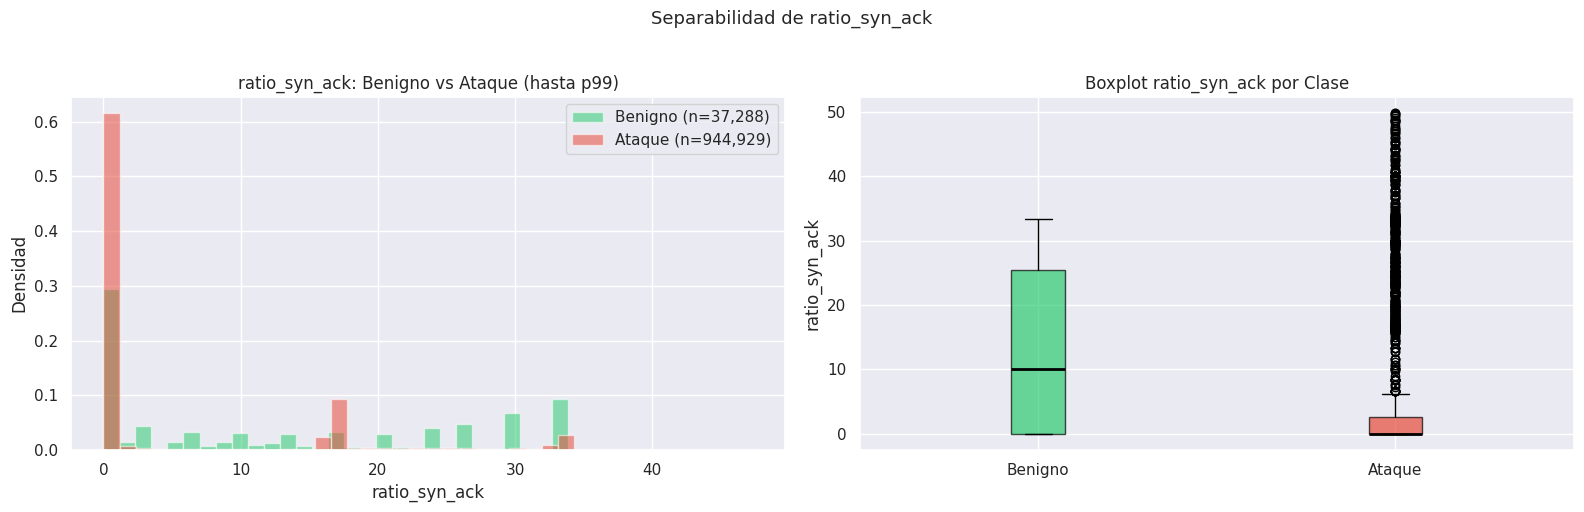

Media ratio_syn_ack — Benigno: 12.7893
Media ratio_syn_ack — Ataque : 6.2767
Diferencia de medias          : 6.5126


In [26]:
idx_benigno = list(le.classes_).index('BenignTraffic')

df_viz = df_train.copy()
df_viz['es_benigno'] = (df_viz['label'] == idx_benigno).map(
    {True: 'Benigno', False: 'Ataque'}
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución ratio_syn_ack (hasta p99 para excluir outliers extremos)
p99 = df_viz['ratio_syn_ack'].quantile(0.99)
for grupo, color in [('Benigno', '#2ecc71'), ('Ataque', '#e74c3c')]:
    subset = df_viz[
        (df_viz['es_benigno'] == grupo) &
        (df_viz['ratio_syn_ack'] <= p99)
    ]['ratio_syn_ack']
    axes[0].hist(subset, bins=40, alpha=0.55, color=color,
                 label=f'{grupo} (n={len(subset):,})', density=True)

axes[0].set_title('ratio_syn_ack: Benigno vs Ataque (hasta p99)', fontsize=12)
axes[0].set_xlabel('ratio_syn_ack')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Boxplot comparativo por clase (muestra de 5000 para velocidad)
muestra_viz = df_viz.sample(5000, random_state=42)
p99_b = muestra_viz['ratio_syn_ack'].quantile(0.99)
muestra_viz_clip = muestra_viz[muestra_viz['ratio_syn_ack'] <= p99_b]

benigno_vals = muestra_viz_clip[
    muestra_viz_clip['es_benigno'] == 'Benigno'
]['ratio_syn_ack'].values
ataque_vals  = muestra_viz_clip[
    muestra_viz_clip['es_benigno'] == 'Ataque'
]['ratio_syn_ack'].values

bp = axes[1].boxplot(
    [benigno_vals, ataque_vals],
    labels=['Benigno', 'Ataque'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.7)
axes[1].set_title('Boxplot ratio_syn_ack por Clase', fontsize=12)
axes[1].set_ylabel('ratio_syn_ack')

plt.suptitle('Separabilidad de ratio_syn_ack', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}feat_eng_ratio_syn_ack.png', bbox_inches='tight')
plt.show()

# Estadísticas de separación
media_benigno = df_viz[df_viz['es_benigno']=='Benigno']['ratio_syn_ack'].mean()
media_ataque  = df_viz[df_viz['es_benigno']=='Ataque']['ratio_syn_ack'].mean()
print(f'Media ratio_syn_ack — Benigno: {media_benigno:.4f}')
print(f'Media ratio_syn_ack — Ataque : {media_ataque:.4f}')
print(f'Diferencia de medias          : {abs(media_ataque - media_benigno):.4f}')

**tasa de activación de flags binarios por clase**

Tasa de activación de flags binarios (%):
                Benigno  Ataque  diferencia
flag_syn_flood    46.46   24.66       21.80
flag_high_rate     1.46    5.14        3.68
flag_low_iat      50.39    3.23       47.17


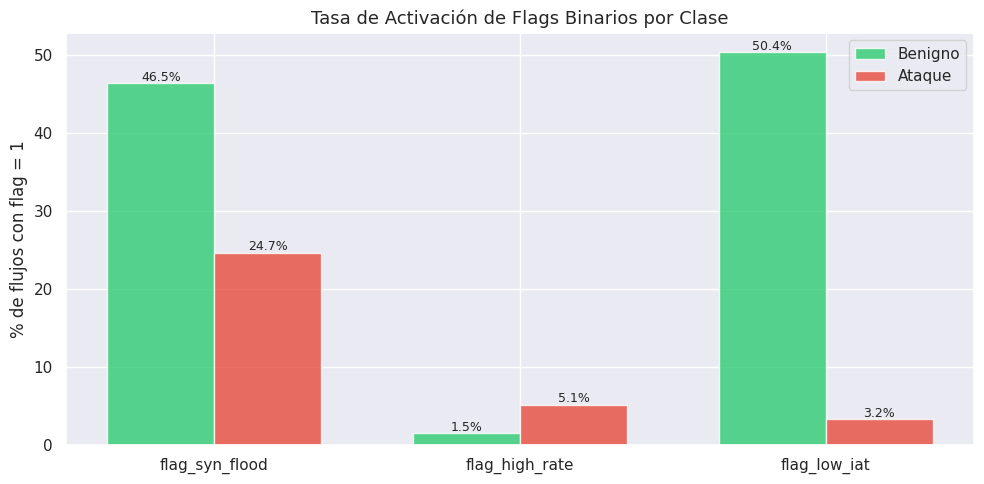

In [27]:
features_flags = ['flag_syn_flood', 'flag_high_rate', 'flag_low_iat']

# Calcular tasa de activación (% de flujos con flag=1) por clase
tasas = {}
for flag in features_flags:
    tasas[flag] = {
        'Benigno': df_viz[df_viz['es_benigno']=='Benigno'][flag].mean() * 100,
        'Ataque' : df_viz[df_viz['es_benigno']=='Ataque'][flag].mean()  * 100
    }

df_tasas = pd.DataFrame(tasas).T
df_tasas['diferencia'] = abs(df_tasas['Ataque'] - df_tasas['Benigno'])
print('Tasa de activación de flags binarios (%):')
print(df_tasas.round(2).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(features_flags))
width = 0.35

bars1 = ax.bar(x - width/2,
               [tasas[f]['Benigno'] for f in features_flags],
               width, label='Benigno', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2,
               [tasas[f]['Ataque']  for f in features_flags],
               width, label='Ataque',  color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(features_flags, fontsize=11)
ax.set_ylabel('% de flujos con flag = 1')
ax.set_title('Tasa de Activación de Flags Binarios por Clase', fontsize=13)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}feat_eng_flags.png', bbox_inches='tight')
plt.show()

## 6.5 Evaluación de Separabilidad

Se mide si las nuevas features **mejoran la capacidad discriminativa del modelo** mediante validación cruzada de 3 folds con F1-weighted. Se comparan dos configuraciones:

1. **Baseline**: solo las 34 features seleccionadas por RF+SHAP
2. **Con nuevas**: las 34 features + las 4 nuevas derivadas válidas

Se usa una muestra estratificada de **30,000 instancias** para que la evaluación sea representativa y computacionalmente manejable.

> **Criterio de inclusión:** Una nueva feature se incorpora al dataset final si su importancia individual ≥ 0.001 (mismo umbral del pipeline de selección original).

In [28]:
# EVALUACIÓN POR CROSS-VALIDATION: BASELINE vs CON NUEVAS
EVAL_SAMPLE = 30_000

idx_eval  = resample(np.arange(len(df_train)),
                     n_samples=EVAL_SAMPLE,
                     stratify=df_train['label'],
                     random_state=42)
df_sample = df_train.iloc[idx_eval].reset_index(drop=True)
y_sample  = df_sample['label'].values

rf_eval = RandomForestClassifier(
    n_estimators=50, max_depth=15, n_jobs=-1, random_state=42
)

# Configuración 1: solo features seleccionadas (baseline)
X_base = df_sample[list(features_sel)].values
scores_base = cross_val_score(
    rf_eval, X_base, y_sample,
    cv=3, scoring='f1_weighted', n_jobs=-1
)

# Configuración 2: features seleccionadas + 4 nuevas válidas
X_new = df_sample[list(features_sel) + NUEVAS_FEATURES].values
scores_new = cross_val_score(
    rf_eval, X_new, y_sample,
    cv=3, scoring='f1_weighted', n_jobs=-1
)

mejora = scores_new.mean() - scores_base.mean()

print('=' * 60)
print('EVALUACIÓN DE SEPARABILIDAD (3-fold CV, n=30,000)')
print('=' * 60)
print(f'F1 Baseline (34 features)     : {scores_base.mean():.4f} ± {scores_base.std():.4f}')
print(f'F1 Con nuevas (34+4 features) : {scores_new.mean():.4f} ± {scores_new.std():.4f}')
print(f'Diferencia                    : {mejora:+.4f}')
print()
if mejora > 0.001:
    print('Las nuevas features MEJORAN la separabilidad.')
elif mejora >= -0.001:
    print('Las nuevas features son NEUTRAS. Se evalúa importancia individual.')
else:
    print('Las nuevas features NO mejoran. Se seleccionan por importancia individual.')

EVALUACIÓN DE SEPARABILIDAD (3-fold CV, n=30,000)
F1 Baseline (34 features)     : 0.9720 ± 0.0011
F1 Con nuevas (34+4 features) : 0.9732 ± 0.0005
Diferencia                    : +0.0011

→ Las nuevas features MEJORAN la separabilidad.
